<a href="https://colab.research.google.com/github/AcharAnusha/Customer-Credit-risk-analysis/blob/main/Customer_Credit_Risk_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

Paisabazaar, a digital loan and credit card platform, helps individuals find and apply for banking and credit products. A key aspect of their business involves assessing customers’ creditworthiness to provide personalized financial recommendations. This case study focuses on analyzing, classifying, and predicting credit scores based on a range of customer data, such as income, credit card usage, and payment behavior. The goal is to help Paisabazaar improve their credit assessment processes, reduce loan defaults, and optimize customer services through better-informed decisions.

# **Business objective**

* Improve the accuracy of credit score classification to better assess the
creditworthiness of customers, minimizing the risk of loan defaults and bad debt.
* Use the predicted credit scores to offer tailored financial products, such as loans, credit cards, and insurance, based on individual financial profiles.
* Provide customers with personalized financial advice and product recommendations, improving customer engagement and trust in Paisabazaar's offerings.

# **Import libraries**

In [ ]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.lines as lines
import matplotlib.image as mpimg
import seaborn as sns

#warnings
import warnings
warnings.filterwarnings('ignore')

# **Understanding the dataset**

In [ ]:
# Load Dataset
bank_df = pd.read_csv('dataset.csv')

In [ ]:
bank_df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,26.822620,265.0,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,5635,3392,2,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,31.944960,266.0,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629162,Good
2,5636,3392,3,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,28.609352,267.0,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good
3,5637,3392,4,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,31.377862,268.0,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good
4,5638,3392,5,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,24.797347,269.0,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good


In [ ]:
# Dimensions of dataset
bank_df.shape

(100000, 28)

In [ ]:
bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  int64  
 1   Customer_ID               100000 non-null  int64  
 2   Month                     100000 non-null  int64  
 3   Name                      100000 non-null  object 
 4   Age                       100000 non-null  float64
 5   SSN                       100000 non-null  float64
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  float64
 10  Num_Credit_Card           100000 non-null  float64
 11  Interest_Rate             100000 non-null  float64
 12  Num_of_Loan               100000 non-null  float64
 13  Type_of_Loan              100000 non-null  ob

In [ ]:
# Missing Values/Null Values Count
bank_df.isnull().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,0
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0


In [ ]:
# Duplicate Value Count
bank_df.duplicated().sum()

np.int64(0)

In [ ]:
# Check Unique Values for each variable.
for column in bank_df.columns:
    print(f'{column} : {len(bank_df[column].unique())}')

ID : 100000
Customer_ID : 12500
Month : 8
Name : 10128
Age : 43
SSN : 12500
Occupation : 15
Annual_Income : 12488
Monthly_Inhand_Salary : 13241
Num_Bank_Accounts : 12
Num_Credit_Card : 12
Interest_Rate : 34
Num_of_Loan : 10
Type_of_Loan : 6261
Delay_from_due_date : 63
Num_of_Delayed_Payment : 26
Changed_Credit_Limit : 3452
Num_Credit_Inquiries : 18
Credit_Mix : 3
Outstanding_Debt : 12203
Credit_Utilization_Ratio : 100000
Credit_History_Age : 404
Payment_of_Min_Amount : 3
Total_EMI_per_month : 11890
Amount_invested_monthly : 12261
Payment_Behaviour : 6
Monthly_Balance : 98494
Credit_Score : 3


# **Data Wrangling**

In [ ]:

bank_df.drop(['Customer_ID','Name','SSN','Month','Payment_of_Min_Amount','ID'],axis = 1, inplace = True)
Q1 = bank_df['Annual_Income'].quantile(0.25)
Q3 = bank_df['Annual_Income'].quantile(0.75)
IQR = Q3 - Q1
bank_df = bank_df[(bank_df['Annual_Income'] >= (Q1 - 1.5 * IQR)) & (bank_df['Annual_Income'] <= (Q3 + 1.5 * IQR))]
bank_df['Annual_Income'].fillna(bank_df['Annual_Income'].mean(), inplace=True)
bank_df['Monthly_Balance'] = pd.to_numeric(bank_df['Monthly_Balance'], errors='coerce')
bank_df['Debt_to_Income_Ratio'] = bank_df['Outstanding_Debt'] / bank_df['Annual_Income']
bank_df['Income_Bracket'] = pd.cut(bank_df['Annual_Income'], bins=[0, 20000, 50000, 100000], labels=['Low', 'Medium', 'High'])

* Dropped unnecessary columns such as customer identifiers and unrelated
attributes to focus on relevant financial and behavioral features.

* Filtered out extreme values in the Annual_Income column, to ensure that outliers do not skew the analysis.

* Filled any missing entries in the Annual_Income column with the mean value to ensure all records have valid income data.

* Converted the Monthly_Balance column to a numeric type, ensuring that calculations involving this column can be performed accurately.

* Introduced a new metric, Debt_to_Income_Ratio, which shows the proportion of a customer's income that goes towards paying debt. This is an important measure of creditworthiness.

* Categorized customers' Annual_Income into three brackets (Low, Medium, High)
to facilitate segmentation and targeted analysis.

# **EDA**

## **Credit Score distribution**

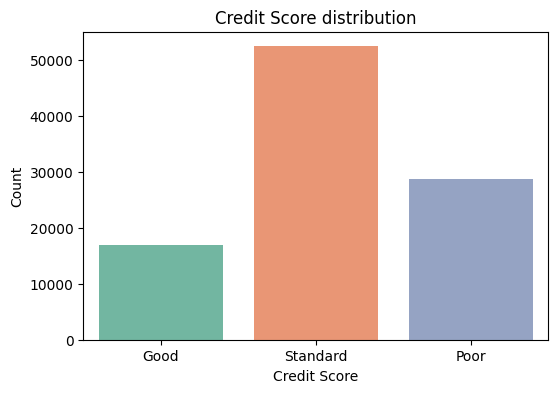

In [ ]:
#Target variable analysis
plt.figure(figsize=(6,4))
sns.countplot(x = 'Credit_Score', data = bank_df, palette= 'Set2')
plt.title('Credit Score distribution')
plt.xlabel('Credit Score')
plt.ylabel('Count')
plt.show()

The Credit Score Distribution chart indicates that most individuals fall within the Standard credit score category. Good credit score customers are the smallest group This distribution suggests opportunities for Paisabazaar to provide targeted financial education and products aimed at improving credit ratings, particularly for those in the Standard category. Additionally, developing tailored services, such as credit-building loans and educational resources, could help customers transition to a Good credit score.

## **Age Demographics**

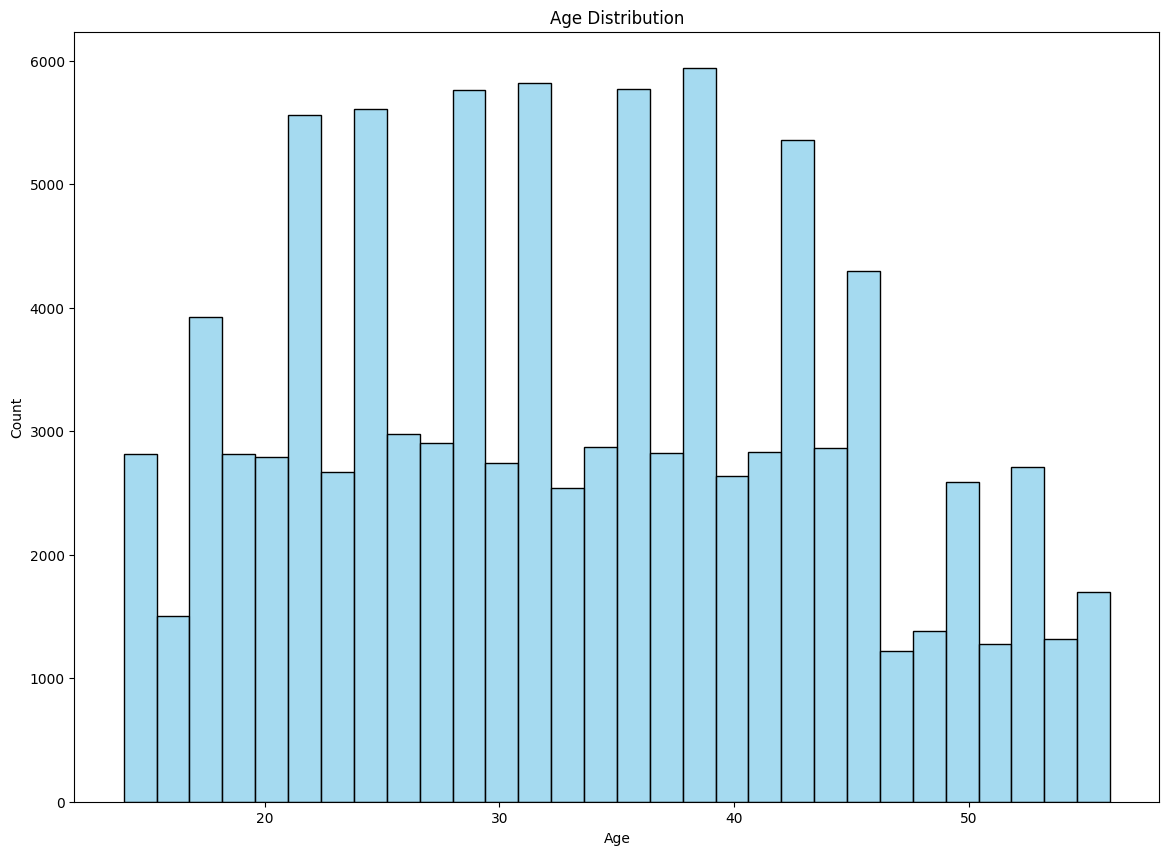

In [ ]:

plt.figure(figsize=(14,10))
sns.histplot(x = 'Age', data = bank_df, bins = 30, color = 'skyblue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

The Age Distribution chart shows that the age group between 30 and 40 years has the highest count of customers, indicating that this demographic is most actively engaged with the services offered. The count gradually decreases for ages below 30 and above 40, suggesting a decline in participation among younger and older age groups. This information can help Paisabazaar tailor their marketing strategies and product offerings to cater specifically to the age group with the highest engagement, while also exploring ways to attract younger customers and retain older clients.

## **Income Distribution**

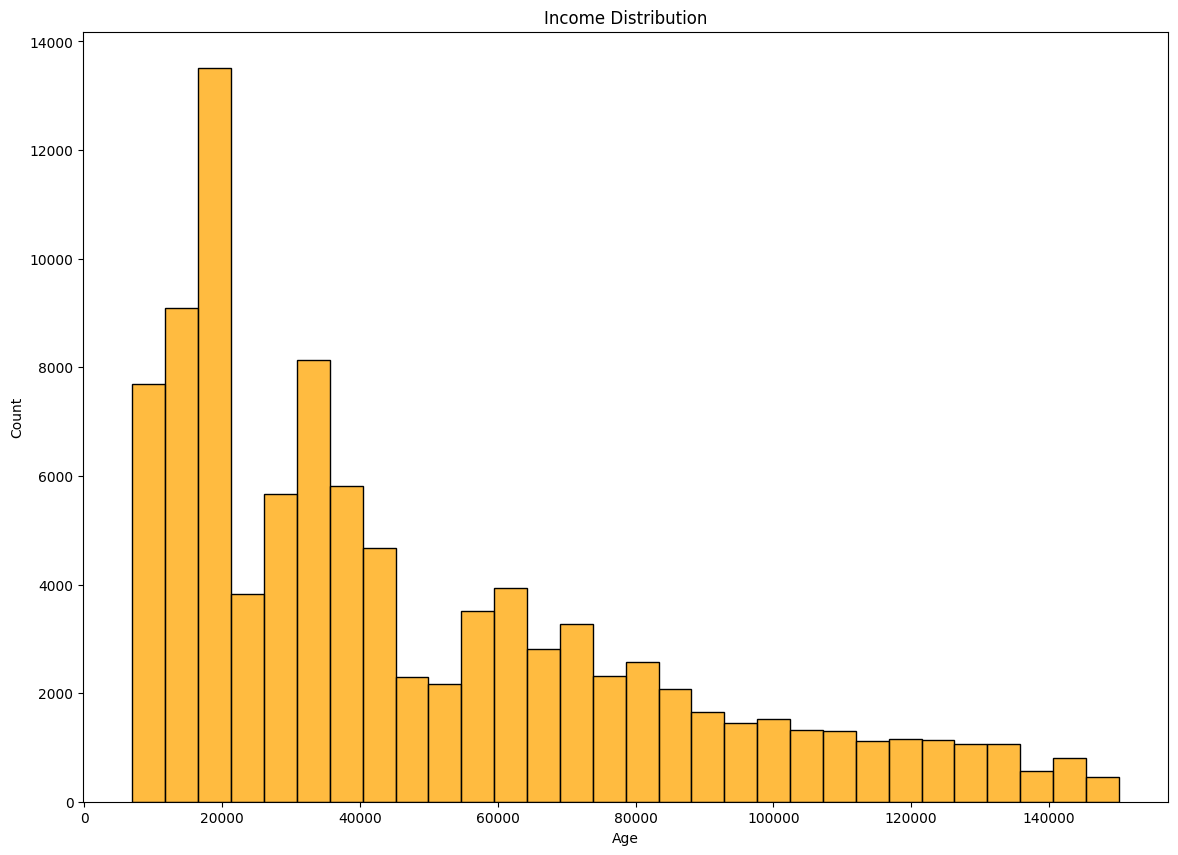

In [ ]:
plt.figure(figsize=(14,10))
sns.histplot(x = 'Annual_Income', data = bank_df, bins = 30, color = 'orange')
plt.title('Income Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

The Distribution of Annual Income and Monthly  chart provides insights
into the financial status of individuals within the dataset.
The chart shows a prominent peak around the 20,000 to 40,000 range,
indicating that a significant number of individuals earn within this bracket. There is a gradual decline as income increases, suggesting a right-skewed distribution. The analysis suggests that a large segment of the population earns modest incomes, and there may be potential opportunities for financial products aimed at individuals within this income range, particularly focusing on budgeting and savings.

**Credit Utilisation**

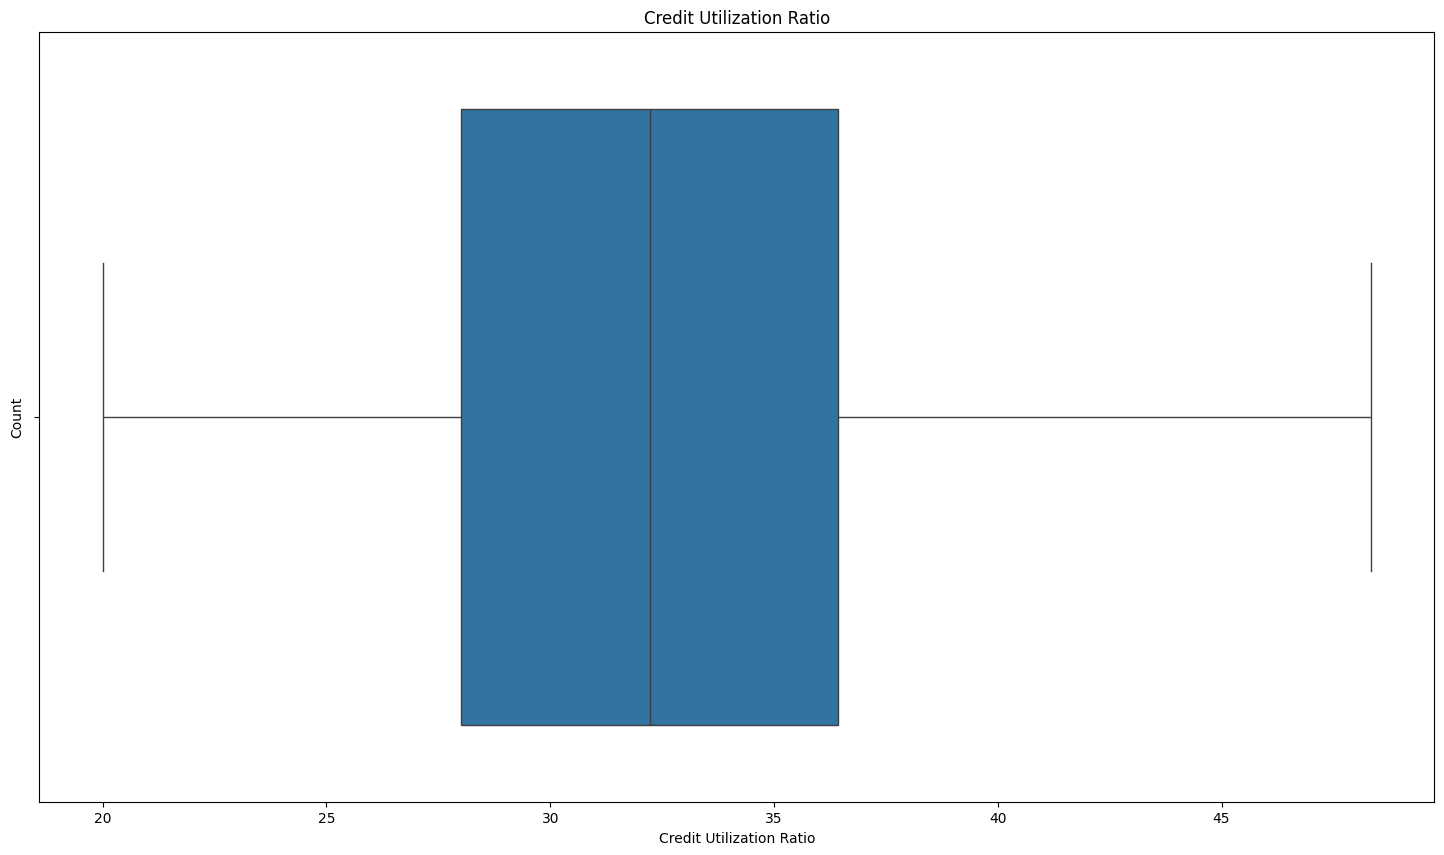

In [ ]:
plt.figure(figsize = (18,10))
sns.boxplot(x ='Credit_Utilization_Ratio', data = bank_df)
plt.title('Credit Utilization Ratio')
plt.xlabel('Credit Utilization Ratio')
plt.ylabel('Count')
plt.show()

The chart analyzes the credit utilization ratio, with values concentrated between approximately 28% to 35%. This analysis indicates that users have credit usage within this range, and deviations outside of it are minimal.

## **Relationship Between Income and Payment Delays**

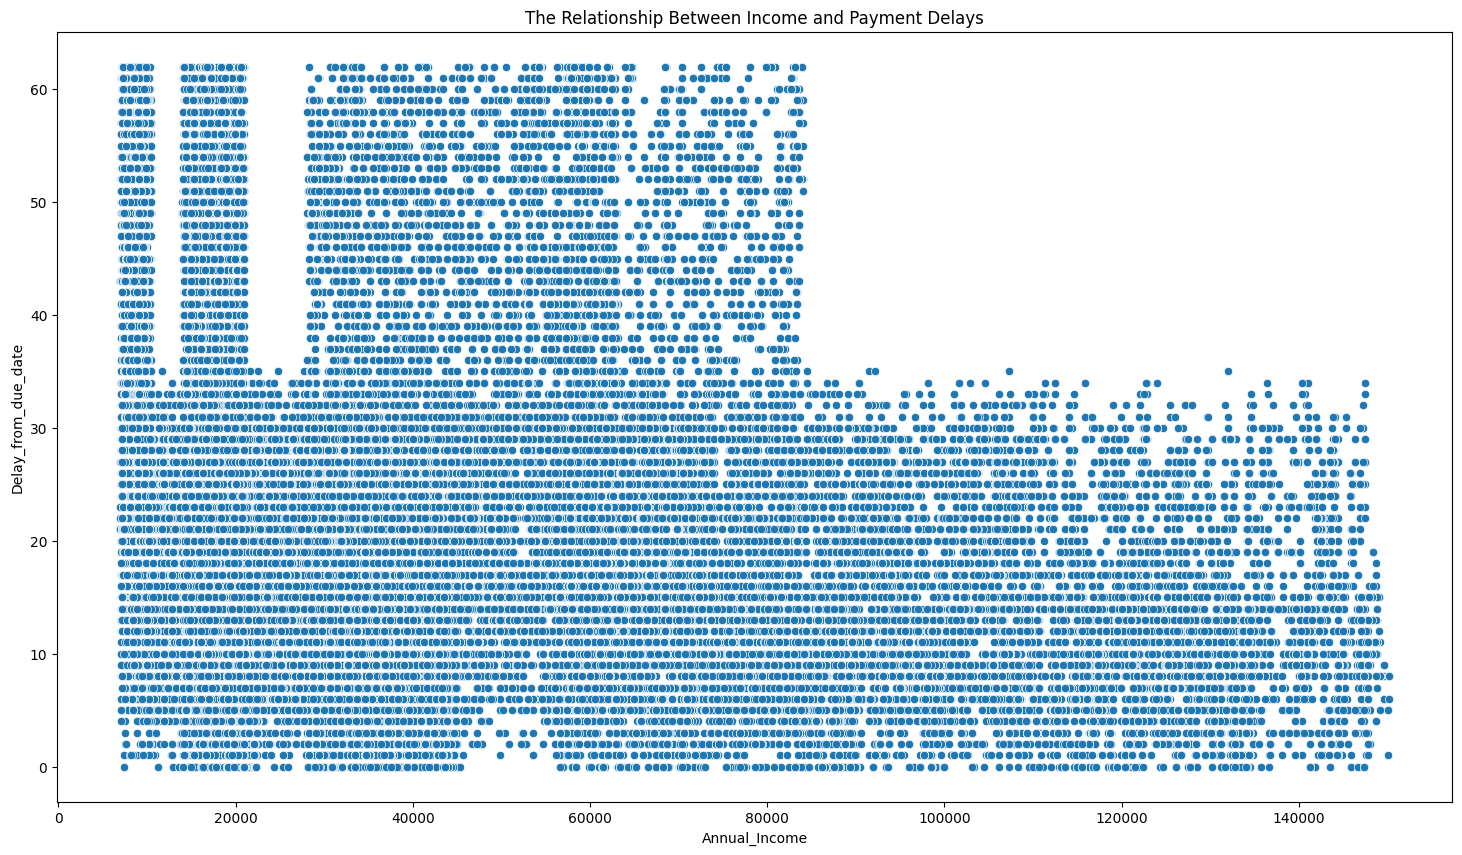

In [ ]:
plt.figure(figsize = (18,10))
sns.scatterplot(x = 'Annual_Income' , y = 'Delay_from_due_date' , data = bank_df)
plt.title('The Relationship Between Income and Payment Delays')
plt.show()

While the data shows a general trend of individuals with lower incomes being more likely to experience payment delays, there are exceptions. A significant portion of individuals across all income levels clear their dues within 30 days, which is a positive indicator of creditworthiness, but it's not a definitive indicator of a customer's creditworthiness.

## **Impact of delayed payments on credit score**

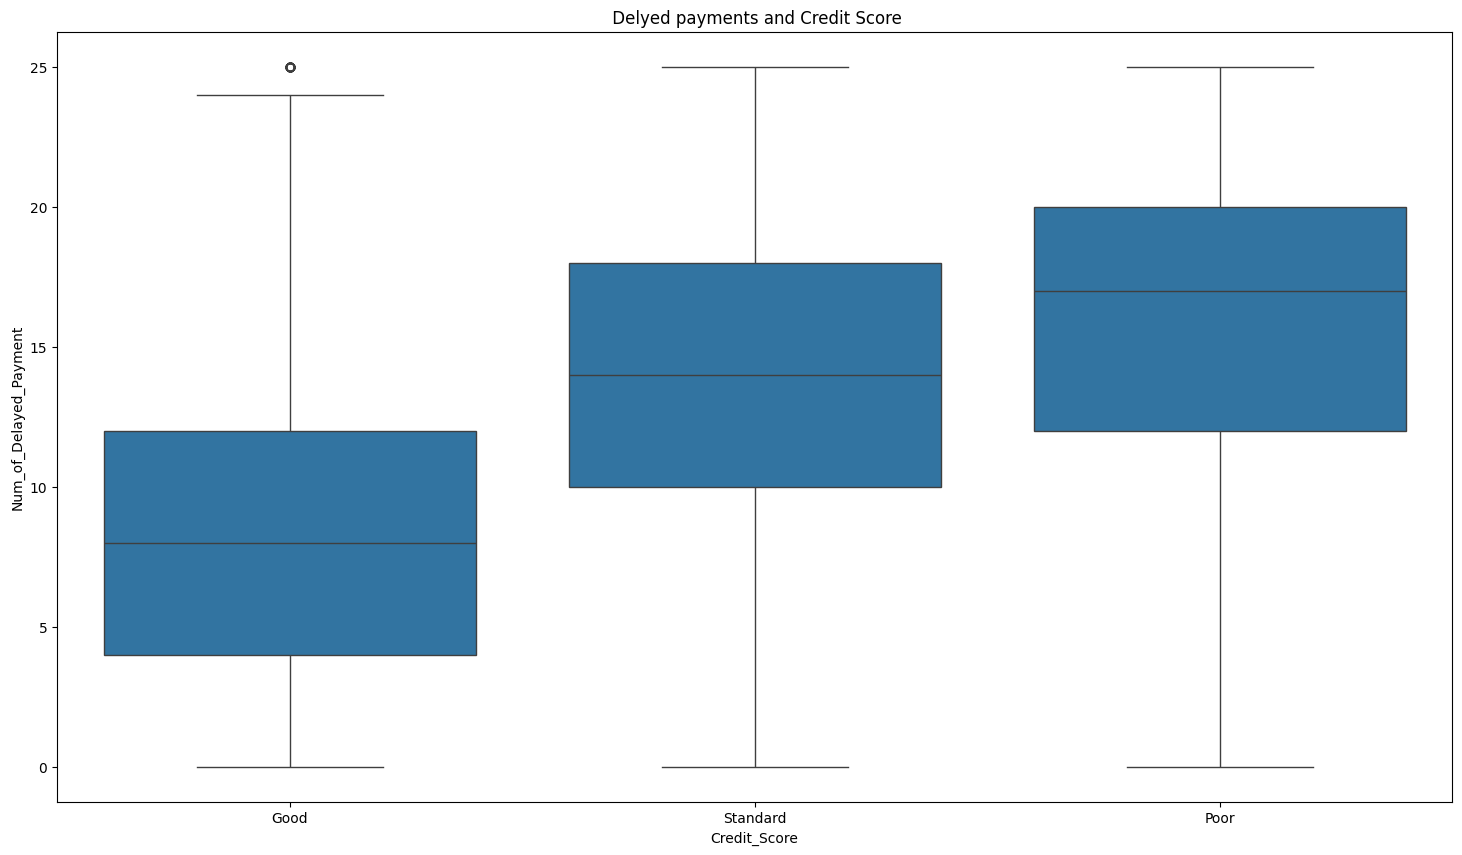

In [ ]:
plt.figure(figsize = (18,10))
sns.boxplot(x = 'Credit_Score' , y = 'Num_of_Delayed_Payment' , data = bank_df)
plt.title(' Delyed payments and Credit Score')
plt.show()

Individuals with good credit scores tend to have fewer delayed payments, ranging from 5 to 12. Those with standard credit scores experience more delayed payments, typically between 10 and 17. For individuals with poor credit scores, the number of delayed payments increases, ranging from 15 to 20. This chart illustrates that a higher number of delayed payments is linked to poorer credit scores.

## **Relationship Between Credit Inquiries and Credit Score**

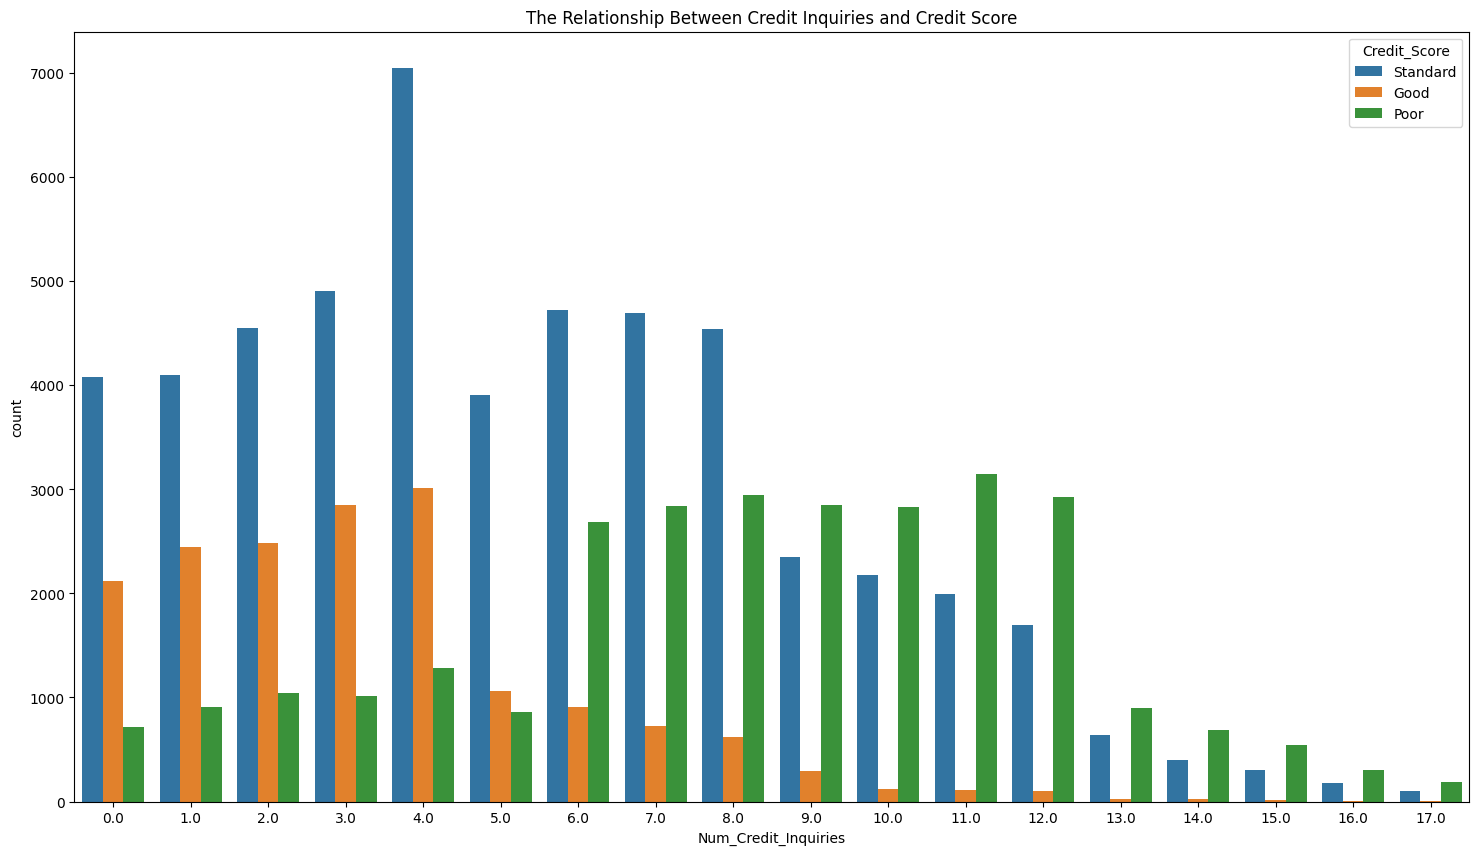

In [ ]:
plt.figure(figsize=(18, 10))
sns.countplot(data=bank_df, x='Num_Credit_Inquiries', hue='Credit_Score')
plt.title('The Relationship Between Credit Inquiries and Credit Score')
plt.show()

The chart shows that as credit inquiries increase, the number of individuals with good credit scores decreases significantly. Standard credit scores also decline because many of these borrowers move into the poor category. However, the poor credit score group remains relatively high because individuals with already low scores tend to make frequent credit applications, so additional inquiries do not significantly change their category.

## **Relationship Between Credit Scores and Bank Account Holdings**

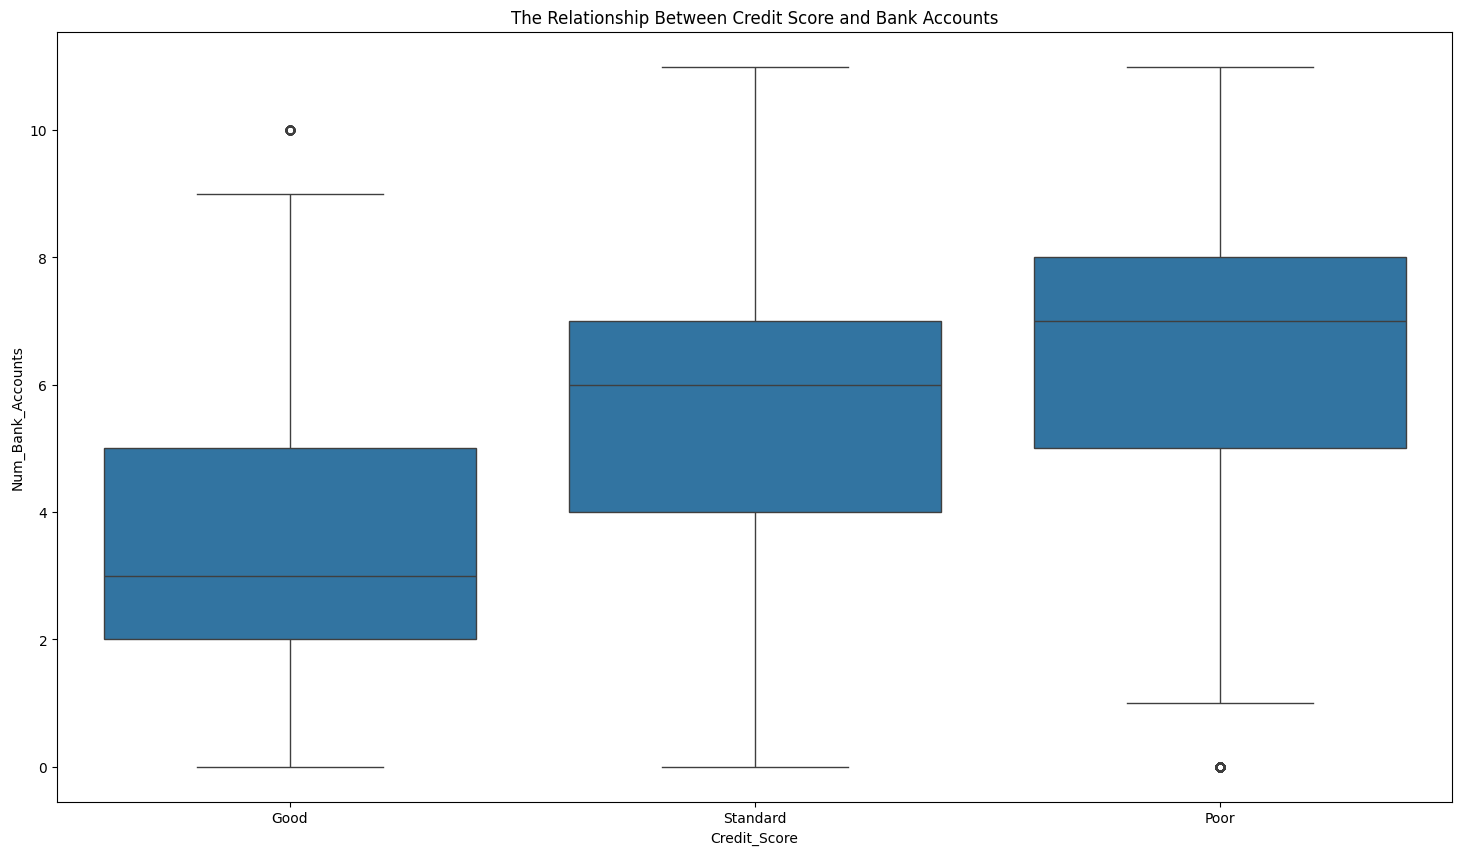

In [ ]:
plt.figure(figsize = (18,10))
sns.boxplot(x = 'Credit_Score' , y = 'Num_Bank_Accounts' , data = bank_df)
plt.title('The Relationship Between Credit Score and Bank Accounts')
plt.show()


People with good credit scores have ~2-5 bank accounts, with median around 3. Customers with standard credit scores have ~4-7 accounts and those with poor credit scores have ~5-8 accounts.This suggests individuals with poor credit scores tend to have a higher number of bank accounts compared to those with good credit scores, indicating that financially unstable individuals maintain multiple credit accounts, which may negatively impact their credit profile.

## **Credit Score distribution across loan types**

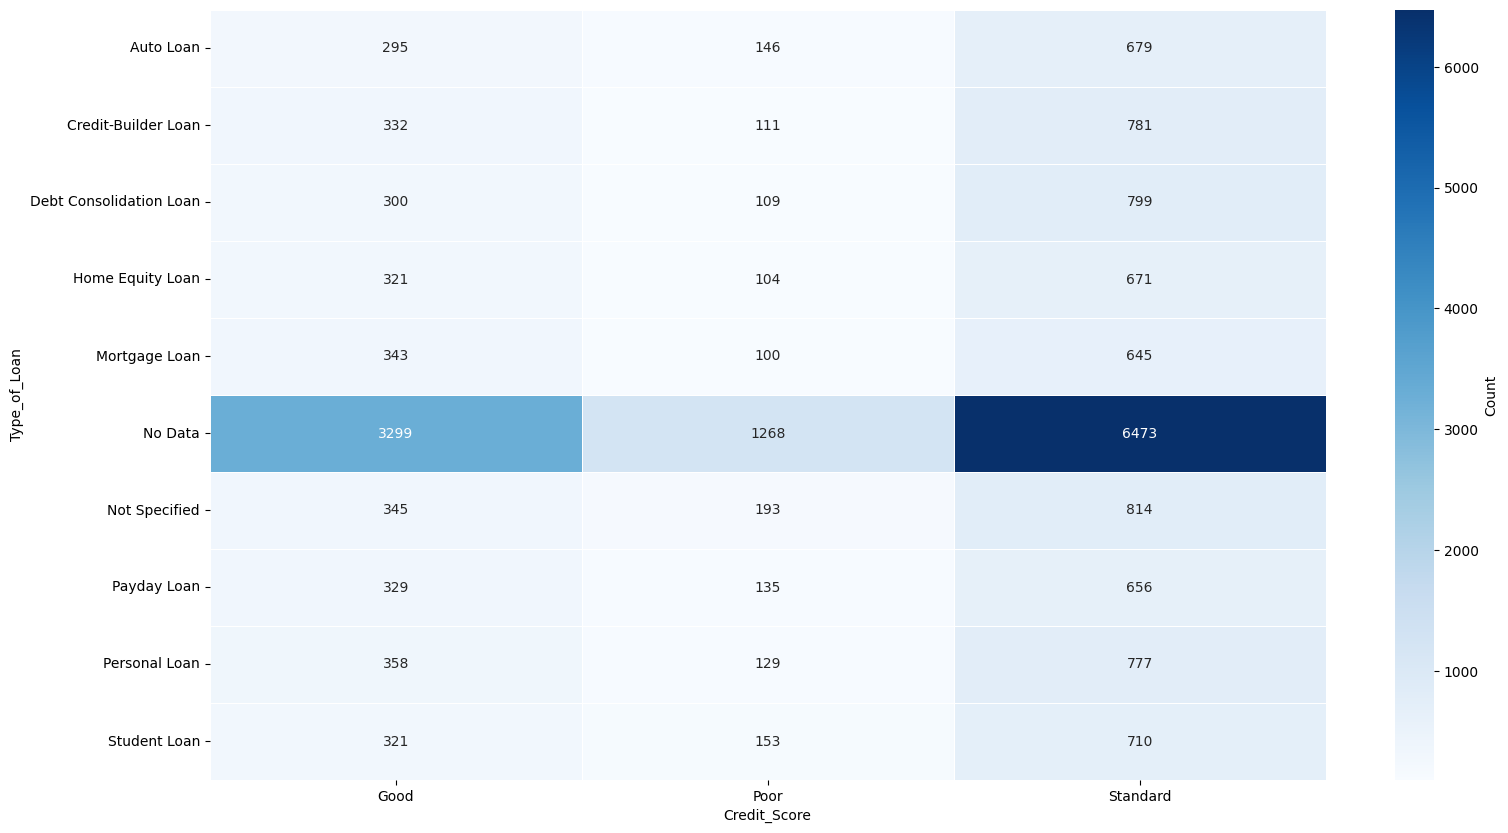

In [ ]:
top_loan_types = bank_df['Type_of_Loan'].value_counts().nlargest(10).index
filtered_bank_df = bank_df[bank_df['Type_of_Loan'].isin(top_loan_types)]
loan_credit_heatmap = filtered_bank_df.groupby(['Type_of_Loan', 'Credit_Score']).size().unstack(fill_value=0)
fig, ax = plt.subplots(1, 1, figsize=(18, 10))
sns.heatmap(loan_credit_heatmap, annot=True, fmt='d', cmap='Blues', ax=ax, cbar_kws={'label': 'Count'}, linewidths=0.5)
plt.show()

The heatmap shows that most borrowers fall into the standard credit score category across all loan types. Poor credit score customers have significantly fewer loans, indicating stricter lending approvals. Additionally, a large portion of the dataset contains missing loan type information, which may represent customers without active loans or incomplete records.